
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 1
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consignas

## Ejercicio 1

Sintetizar:
- Señal sinusoidal de 2KHz
- Misma señal amplificada 3 dB y desfazada en $\frac{\pi}{2}$
- Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.
- Señal anterior recortada al 75% de su amplitud. Ayuda: ver numpy.clip().
- Una señal cuadrada de 4KHz
- Un pulso rectangular de 10ms

En cada caso indique: período, número de muestras y si se trata de una señal de potencia o energía según corresponda.

## Ejercio 2

Dado $h[n] = \delta[n] - \delta[n - 4]$, encontrar $y[n] = x[n] * h[n]$ para cada una de las siguientes $x[n]$:

a) $x[n] = cos(w_{0}.n.T_{s})$. Expresar la respuesta como un único coseno de la forma $A . cos(w_{0}.n.T_{s} + \phi)$.

b) $x[n] = (1/2)^n . u[n]$

c) $x[n] = u[n + 1] - u[n - 2]$

## Resolución ejercicio 1
### Definición de funciones

A continuación, se presenta el bloque de codigo con las definiciones de las funciones que se serán utilizadas a lo largo de este trabajo

In [1]:
import numpy as np

# función para sintetizar señales senoidales.
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):

    # tiempo de muestreo
    ts = 1/fs
    
    # vector de tiempo
    tt = np.linspace(0, (nn-1)*ts, nn)
    
    # señal senoidal
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    
    return tt, xx

# función para calular la potencia media de una señal.
def potencia_media(xx):
    pp = np.mean(xx ** 2)
    return pp

# función para calular la energía de una señal.
def energia(xx, ts):
    ee = np.sum(xx ** 2) * ts
    return ee

### Señal sinusiodal de 2KHz

Para este primer caso, se sintetiza una señal senoidal pura. Se define una frecuencia de muestreo de $F_S = 50 \text{ kHz}$, lo cual cumple ampliamente con el Teorema de Nyquist ($F_S > 2 \cdot f_{max}$), evitando así el solapamiento (aliasing) y permitiendo una representación clara de la forma de onda.

── Señal 1: Sinusoide 2 kHz ──────────────────
  Δt         = 20.0000 µs
  Período    = 0.50 ms
  N muestras = 250
  Duración   = 5.00 ms
  Potencia   = 0.500000 W 


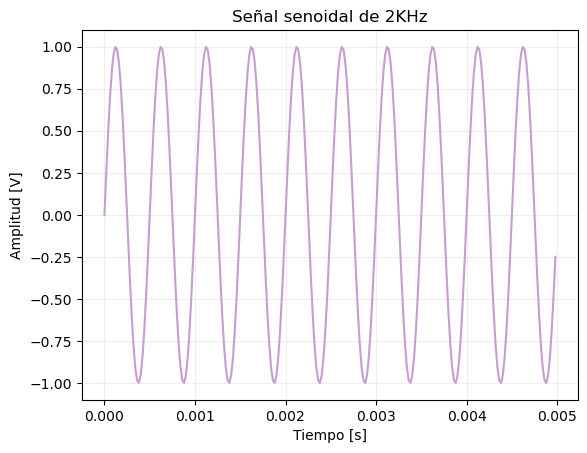

In [2]:
import matplotlib.pyplot as plt

FS = 50000          # Nyquist fs >>= 2*ff
TS = 1 / FS         # tiempo entre muestras

ff1 = 2000
N1  = int(10 / ff1 * FS)   # 10 ciclos de 2kHz → 250 muestras

tt1, xx1 = mi_funcion_sen(vmax=1, dc=0, ff=ff1, ph=0, nn=N1, fs=FS)  # nn=N1, no nn=N
P1 = potencia_media(xx1)

print("── Señal 1: Sinusoide 2 kHz ──────────────────")
print(f"  Δt         = {TS*1e6:.4f} µs")
print(f"  Período    = {1/ff1*1e3:.2f} ms")
print(f"  N muestras = {N1}")
print(f"  Duración   = {N1*TS*1e3:.2f} ms")
print(f"  Potencia   = {P1:.6f} W ")

plt.plot(tt1, xx1, color='#C69DD2')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 2KHz")
plt.grid(True, alpha=0.2)
plt.show()

Debido a que la amplitud máxima establecida ($V_{max}$) es de $1$, y a que el valor teórico de potencia para una sinusoide pura es $P = \frac{V_{max}^2}{2}$, el valor para la potencia deberia dar cercano a $0.5 \text{ W}$. Efectivamente, esto se verifica al ver el resultado de aplicar la funcion potencia_media.

### Misma señal amplificada $3\text{ dB}$ y desfazada en $\pi / 2$

Se aplica una transformación sobre la señal original de $2 \text{ kHz}$ mediante la modificación simultánea de su ganancia y su posición temporal relativa. Por lo que, se incorpora un desplazamiento de fase de $\pi/2$ radianes y se modifica la amplitud teniendo en cuenta que:
$$3\text { dB} = 20 . log (v_{max2}/v_{max1})$$
$$3\text { dB} / 20 = log (v_{max2})$$
$$v_{max2} = 10^{3/20}$$



── Señal 2: Amplificada 3 dB y desfasada π/2 ───
  Δt          = 20.0000 µs
  Período     = 0.50 ms
  N muestras  = 250
  Duración    = 5.00 ms
  Potencia    = 0.997631 W 


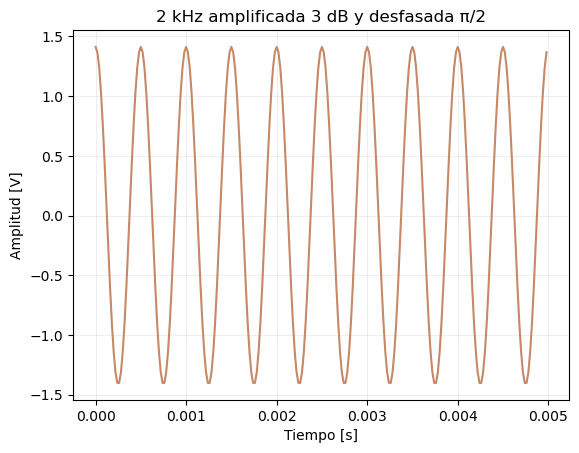

In [3]:
ff2   = 2000
vmax2 = 10**(3/20)  # +3 dB -- > vmax2 aprox = 1,414 V
ph2   = np.pi / 2
N2    = N1   # misma duración
tt2, xx2 = mi_funcion_sen(vmax=vmax2, dc=0, ff=ff2, ph=ph2, nn=N2, fs=FS)
 
P2 = potencia_media(xx2)
print("\n── Señal 2: Amplificada 3 dB y desfasada π/2 ───")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  Período     = {1/ff2*1e3:.2f} ms")
print(f"  N muestras  = {N2}")
print(f"  Duración    = {N2*TS*1e3:.2f} ms")
print(f"  Potencia    = {P2:.6f} W ")

plt.plot(tt2, xx2,color='#C68866')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("2 kHz amplificada 3 dB y desfasada π/2")
plt.grid(True, alpha=0.2)

plt.show()

En el proximo bloque se codigo, se grafican las formas de onda de ambas señales para su comparación.

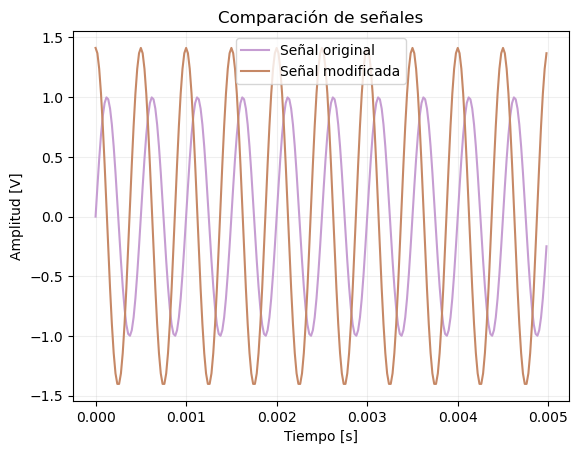

  Potencia de la señal original    = 0.500000 W 
  Potencia de la señal modificada  = 0.997631 W 


In [4]:

plt.plot(tt1, xx1,color='#C69DD2', label = 'Señal original')
plt.plot(tt2, xx2,color='#C68866', label = 'Señal modificada')
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Comparación de señales")
plt.grid(True, alpha=0.2)

plt.show()

print(f"  Potencia de la señal original    = {P1:.6f} W ")
print(f"  Potencia de la señal modificada  = {P2:.6f} W ")


Incrementar la amplitud máxima en $3 \text{ dB}$ resulta igual a multiplicar la señal por $\sqrt{2} \approx 1.414 \text{ V}$. Debido a que la potencia media es proporcional al cuadrado de dicha amplitud, la potencia resultante es el doble de la original, ya que $ (\sqrt{2})^2 = 2$
. Esto se verifica al ver los resultados obtenidos: $0.997631 \text{ W} \approx 1 \text{ W} = 2 * 0.5 \text{ W}$

El desplazamiento de fase de $\pi/2$ radianes, desplaza la forma de onda en el tiempo, transformando la función seno en una función coseno, lo que permite observar cómo el punto de inicio de la oscilación cambia respecto al origen sin alterar la frecuencia fundamental de $2 \text{ kHz}$. 

### Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia

En esta etapa del ejercicio se procede a realizar la modulación en amplitud de la señal original de $2 \text{ kHz}$, la cual actúa como portadora. Para este proceso, se introduce una segunda señal senoidal denominada moduladora, cuya frecuencia se establece en la mitad de la anterior, es decir, $1 \text{ kHz}$. La implementación consiste en el producto punto a punto de ambas señales, lo que genera una envolvente variable que modifica la intensidad de la portadora en función del tiempo.

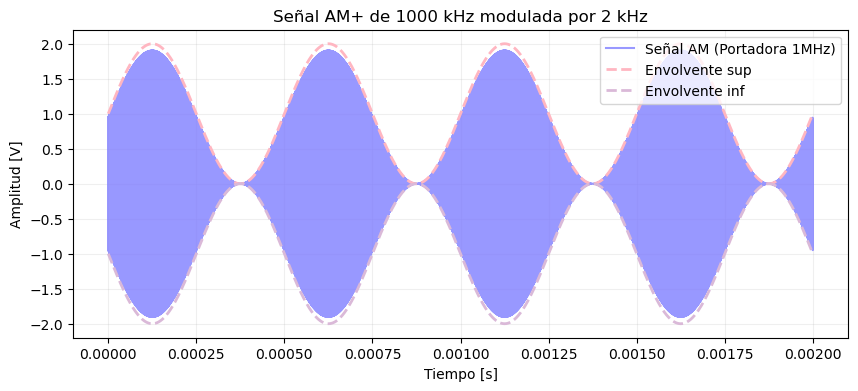

── Señal 3: AM+ (portadora 2kHz, moduladora 1kHz) ──
  Índice de modulación m = 1
  Δt         = 0.1000 µs
  Período    = 0.50 ms
  N muestras = 20000
  Duración   = 400.00 ms
  Potencia   = 0.750000 W 


In [15]:
import matplotlib.pyplot as plt

ff_moduladora = 2000      # Señal original de 2 kHz
ff_portadora = 1000e3     # Portadora de 1000 kHz (1 MHz) 
m = 1                  # índice de modulación (0 < m <= 1 para no sobremodular)

FS_mod = 10e6

N3 = int((4 / ff_moduladora) * FS_mod)

tt3, portadora = mi_funcion_sen(vmax=1, dc=0, ff=ff_portadora, ph=0, nn=N3, fs=FS_mod)
tt3, moduladora = mi_funcion_sen(vmax=1, dc=0, ff=ff_moduladora, ph=0, nn=N3, fs=FS_mod)

# AM+: envolvente nunca cruza cero → sin sobremodulación
xx3 = (1 + m * moduladora) * portadora

P3 = potencia_media(xx3)
envolvente = 1 + m * moduladora

plt.figure(figsize=(10, 4))
plt.plot(tt3, xx3, color='#7F7EFF', label="Señal AM (Portadora 1MHz)", alpha=0.8)
plt.plot(tt3, envolvente, '--', color='#FFB6C1', label="Envolvente sup", linewidth=2)
plt.plot(tt3, -envolvente, '--', color='#DAB9D8', label="Envolvente inf", linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal AM+ de 1000 kHz modulada por 2 kHz")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("── Señal 3: AM+ (portadora 2kHz, moduladora 1kHz) ──")
print(f"  Índice de modulación m = {m}")
TS_mod = 1/FS_mod
print(f"  Δt         = {TS_mod*1e6:.4f} µs")
print(f"  Período    = {1/ff_moduladora*1e3:.2f} ms")
print(f"  N muestras = {N3}")
print(f"  Duración   = {N3*TS*1e3:.2f} ms")
print(f"  Potencia   = {P3:.6f} W ")



Como puede observarse en el gráfico, la señal modulada presenta una oscilación rápida 
correspondiente a la portadora de $f_c = 1000$ kHz, cuya amplitud varía lentamente 
siguiendo la envolvente dictada por la señal moduladora de $f_{mod} = 2$ kHz.
Debido a la gran diferencia entre ambas frecuencias (razón de $500:1$), los ciclos 
individuales de la portadora no son distinguibles a la escala temporal del gráfico, 
generando el aspecto de zona "rellena" característico de este tipo de señales.
Se incorporó la representación de la envolvente superior e inferior con el objetivo 
de visualizar de manera más clara el efecto de la modulación en amplitud, evidenciando 
cómo la señal moduladora controla la variación de la amplitud de la portadora a lo 
largo del tiempo.

Al observar los resultados numéricos y el gráfico, se evidencia un incremento en la 
potencia media respecto a la portadora sin modular, pasando de $0.50$ W a $0.75$ W.
Este fenómeno se explica porque la señal AM+ incorpora tanto la potencia de la portadora 
como la potencia de las bandas laterales. Con índice de modulación $m = 1$, la potencia 
total resulta:

$$P = P_c \cdot \left(1 + \frac{m^2}{2}\right) = 0.5 \cdot \left(1 + \frac{1}{2}\right) = 0.5 \cdot 1.5 = 0.75 \text{ W}$$

lo cual es consistente con el resultado obtenido numéricamente.


#### Zoom sobre la señal AM+

Al graficar la señal AM+ completa, la alta frecuencia de la portadora ($f_c = 1000$ kHz) 
genera una densidad de ciclos tan elevada que resulta imposible distinguirlos a escala global.
Para visualizar las oscilaciones individuales de la portadora y cómo la envolvente las modula,
se realiza un zoom sobre los primeros $10\ \mu s$ de la señal.

En esta ventana temporal se aprecian aproximadamente **10 ciclos** de la portadora, 
suficientes para observar su forma sinusoidal individual. Nótese que la envolvente 
permanece casi constante en este intervalo, dado que el período de la señal moduladora es:

$$T_{mod} = \frac{1}{f_{mod}} = \frac{1}{2000} = 500\ \mu s$$

Es decir, $10\ \mu s$ representa apenas el $2\%$ de un ciclo completo de la moduladora, 
por lo que la variación de amplitud es prácticamente imperceptible a esta escala.

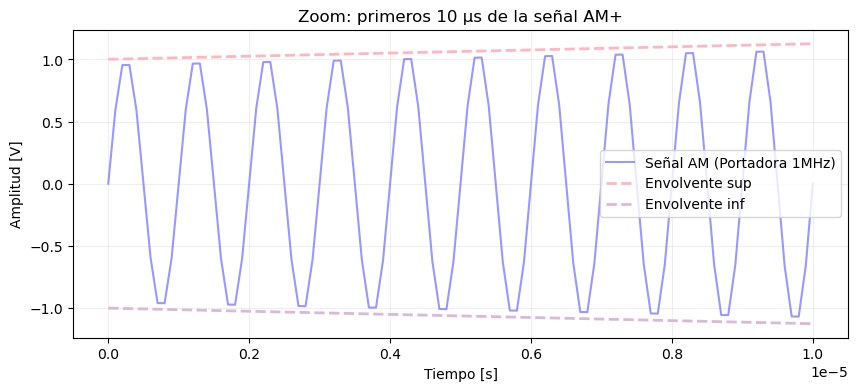

In [16]:
t_zoom = 10e-6  # ventana de 10 µs → ~10 ciclos de portadora

mask = tt3 <= t_zoom

plt.figure(figsize=(10, 4))
plt.plot(tt3[mask], xx3[mask], color='#7F7EFF', label="Señal AM (Portadora 1MHz)", alpha=0.8)
plt.plot(tt3[mask], envolvente[mask], '--', color='#FFB6C1', label="Envolvente sup", linewidth=2)
plt.plot(tt3[mask], -envolvente[mask], '--', color='#DAB9D8', label="Envolvente inf", linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Zoom: primeros 10 µs de la señal AM+")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### Señal anterior recortada al 75% de su amplitud

Para esta parte de la consigna se utilizó la función *np.clip* de la biblioteca NumPy. Esta herramienta permite limitar (o acotar) los valores de un arreglo dentro de un rango definido. Es decir, los datos que caen fuera de este límite se ajustan a los extremos del mismo. Por ejemplo, si se establece el intervalo [0, 1], cualquier valor menor a 0 adopta el valor 0, y cualquier valor mayor a 1 se convierte en 1.


── Señal 4: AM recortada al 75 % (clipping) ──────
  Δt          = 20.0000 µs
  Período     = 1.00 ms
  N muestras  = 20000  (misma duración que señal 3)
  Duración    = 400.00 ms
  Potencia    = 0.273259 W 


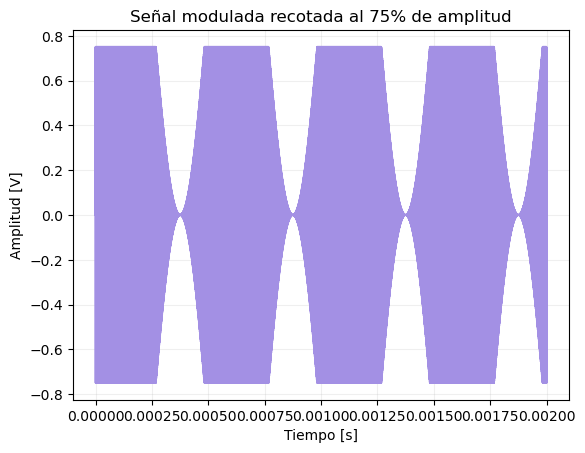

In [8]:
ff_moduladora = 1000   # mitad de la portadora

clip_level = 0.75
xx4 = np.clip(xx3, -clip_level, clip_level)
 
P4 = potencia_media(xx4)
print("\n── Señal 4: AM recortada al 75 % (clipping) ──────")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  Período     = {1/ff_moduladora*1e3:.2f} ms")
print(f"  N muestras  = {N3}  (misma duración que señal 3)")
print(f"  Duración    = {N3*TS*1e3:.2f} ms")
print(f"  Potencia    = {P4:.6f} W ")

plt.plot(tt3, xx4, color='#A390E4')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal modulada recotada al 75% de amplitud")
plt.grid(True, alpha=0.2)

plt.show()

Comparando con la señal modulada sin recortar:

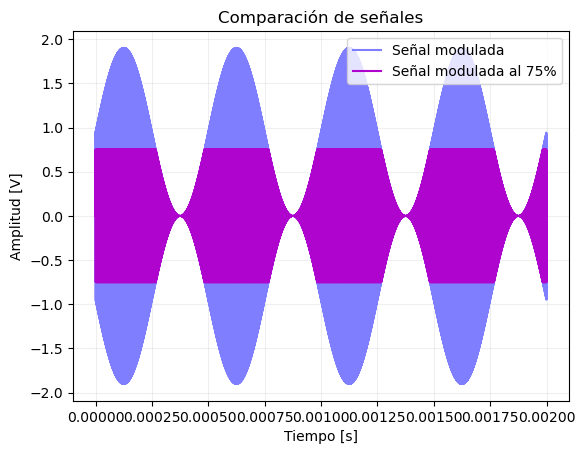

  Potencia de la señal original           = 0.750000 W 
  Potencia de la señal recortada al 75%   = 0.273259 W 


In [9]:

plt.plot(tt3, xx3,color='#7F7EFF', label = 'Señal modulada')
plt.plot(tt3, xx4,color='#AF04CD', label = 'Señal modulada al 75%')
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Comparación de señales")
plt.grid(True, alpha=0.2)

plt.show()

print(f"  Potencia de la señal original           = {P3:.6f} W ")
print(f"  Potencia de la señal recortada al 75%   = {P4:.6f} W ")

El "recorte" consiste en limitar la amplitud de la señal al 75% de su valor máximo original, eliminando los picos de tensión que exceden dicho umbral. Al observar los resultados, se evidencia una reducción drástica de la potencia media, la cual cae de $0.75 \text{ W}$ a aproximadamente $0.257 \text{ W}$.

### Una señal cuadrada de 4KHz

En esta etapa del trabajo se procede a la generación de una señal cuadrada con una frecuencia fundamental de $4 \text{ kHz}$, lo que representa el doble de la frecuencia utilizada en los casos anteriores.


── Señal 5: Cuadrada 4 kHz ────────────────────
  Δt          = 20.0000 µs
  Período     = 0.25 ms
  N muestras  = 125
  Duración    = 2.50 ms
  Potencia    = 1.000000 W 


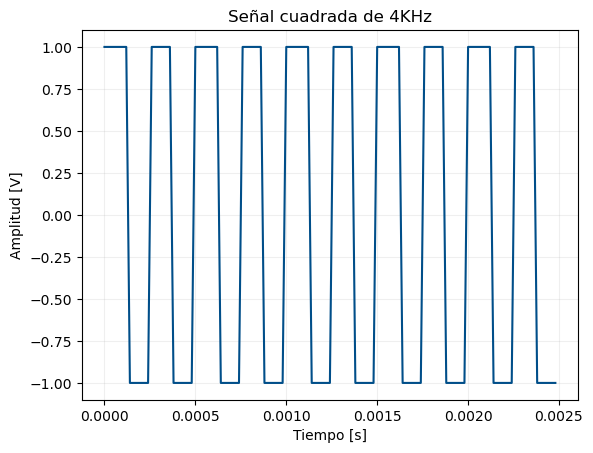

In [10]:
from scipy import signal as sig

ff5 = 4000
N5  = int(10 / ff5 * FS)   # 10 ciclos
tt5 = np.linspace(0, (N5 - 1) * TS, N5)
xx5 = sig.square(2 * np.pi * ff5 * tt5)   # amplitud ±1
 
P5 = potencia_media(xx5)
print("\n── Señal 5: Cuadrada 4 kHz ────────────────────")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  Período     = {1/ff5*1e3:.2f} ms")
print(f"  N muestras  = {N5}")
print(f"  Duración    = {N5*TS*1e3:.2f} ms")
print(f"  Potencia    = {P5:.6f} W ")

plt.plot(tt5, xx5, color='#004E89')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuadrada de 4KHz")
plt.grid(True, alpha=0.2)

plt.show()

La síntesis de la señal cuadrada de $4 \text{ kHz}$ permite observar un comportamiento distintivo en comparación con las señales senoidales. A diferencia de las funciones suaves, la señal cuadrada alterna instantáneamente entre sus valores máximos y mínimos ($1 \text{ V}$ y $-1 \text{ V}$), lo que resulta en una potencia media de exactamente $1.00 \text{ W}$. Este valor se debe a que, al elevar la señal al cuadrado, el resultado es una constante de valor $1$ durante todo el intervalo de tiempo (ya que $1^2 = 1$ y $(-1)^2 = 1$).

Si bien ambas señales (la senoidal de $2 \text{ kHz}$ y la cuadrada de $4 \text{ kHz}$) tienen la misma amplitud, sus valores para la potencia media son distintos: $P_{senoidal} = 0.5 \text{W}$ y $P_{cuadrada} = 1 \text{W}$. Esto se debe a que la señal cuadrada "llena" todo el área del gráfico al estar siempre en su valor máximo (positivo o negativo), mientras que la senoidal pasa la mayor parte del tiempo en valores intermedios.

### Un pulso rectangular de 10ms

Para finalizar el primer ejercicio, se sintetiza un pulso rectangular de duración finita establecido en $10 \text{ ms}$. 


── Señal 6: Pulso rectangular 10 ms ──────────
  Δt          = 20.0000 µs
  N muestras  = 1000  (ventana de 20 ms)
  N en pulso  = 500
  Energía     = 0.010020 J
  * Señal de ENERGÍA finita (no de potencia)


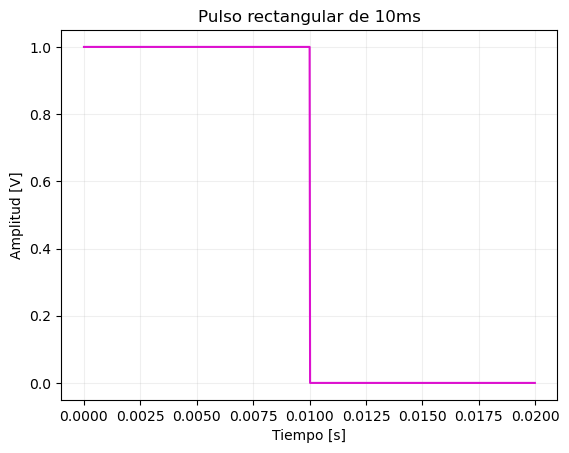

In [11]:
T_ventana = 0.020           # 20 ms de observación
duracion_pulso = 0.010      # 10 ms de duración del pulso
N6 = int(T_ventana * FS)
tt6 = np.linspace(0, (N6 - 1) * TS, N6)
xx6 = np.zeros(N6)
xx6[tt6 <= duracion_pulso] = 1
 
E6 = energia(xx6, TS)
print("\n── Señal 6: Pulso rectangular 10 ms ──────────")
print(f"  Δt          = {TS*1e6:.4f} µs")
print(f"  N muestras  = {N6}  (ventana de {T_ventana*1e3:.0f} ms)")
print(f"  N en pulso  = {int(duracion_pulso*FS)}")
print(f"  Energía     = {E6:.6f} J")
print(f"  * Señal de ENERGÍA finita (no de potencia)")

plt.plot(tt6, xx6, color='#DD10CF')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Pulso rectangular de 10ms")
plt.grid(True, alpha=0.2)

plt.show()

A diferencia de las señales sinusoidales o cuadradas analizadas previamente, este pulso no es una señal periódica de potencia, sino una señal de energía. Debido a su naturaleza transitoria, el cálculo de la potencia media sobre un intervalo infinito tendería a cero, por lo cual se utiliza la función de energía para cuantificar la intensidad total de la señal en su intervalo de existencia. 

## Señales de Energía vs. Señales de Potencia

Para finalizar el análisis de las señales sintetizadas, se procede a su clasificación según su contenido energético a lo largo del tiempo. Esta distinción es fundamental, ya que determina qué parámetro físico describe mejor el comportamiento de la señal:

* **Señales de Potencia**: En este grupo se encuentran la señal sinusoidal (en todas sus variantes de fase y amplitud), la señal modulada (AM) y la señal cuadrada. Dado que estas señales son periódicas (o cuasi-periódicas) y se extienden teóricamente desde $-\infty$ hasta $+\infty$, su energía total es infinita. Por lo tanto, se caracterizan mediante su potencia media, que representa la energía distribuida por unidad de tiempo. En la práctica, al trabajar con una ventana finita de ciclos, el cálculo de la potencia media nos permite obtener un valor estable y representativo de la señal.

* **Señales de Energía**: El pulso rectangular de $10 \text{ ms}$ es el único caso en este trabajo que clasifica estrictamente como una señal de energía. Al ser un evento transitorio de duración finita que vale cero fuera de su intervalo de definición, su potencia media calculada sobre un tiempo infinito tendería a cero. En cambio, su energía total es un valor finito y medible que representa la magnitud del pulso.

Esta clasificación nos permite concluir que, mientras que para las primeras cinco señales el cálculo relevante fue el valor cuadrático medio (potencia), para el pulso rectangular el dato físico de interés es la integral del cuadrado de su amplitud (energía).

## Resolución ejercicio 2

Para esta parte del trabajo, se realizó el ejercicio propuesto inicialmente de forma analítica (manual). Posteriormente, se procedió a corroborar los resultados obtenidos mediante el uso de las herramientas gráficas presentadas en clase.

Adjunto: PDF con la resolución detallada y gráficos aproximados realizados a mano.

In [12]:
from IPython.display import IFrame
IFrame("TS1.pdf", width=800, height=600)

Se procedió a calcular y graficas la respuesta del sistema para los distintos valores de entrada $x[n]$ propuestos. 

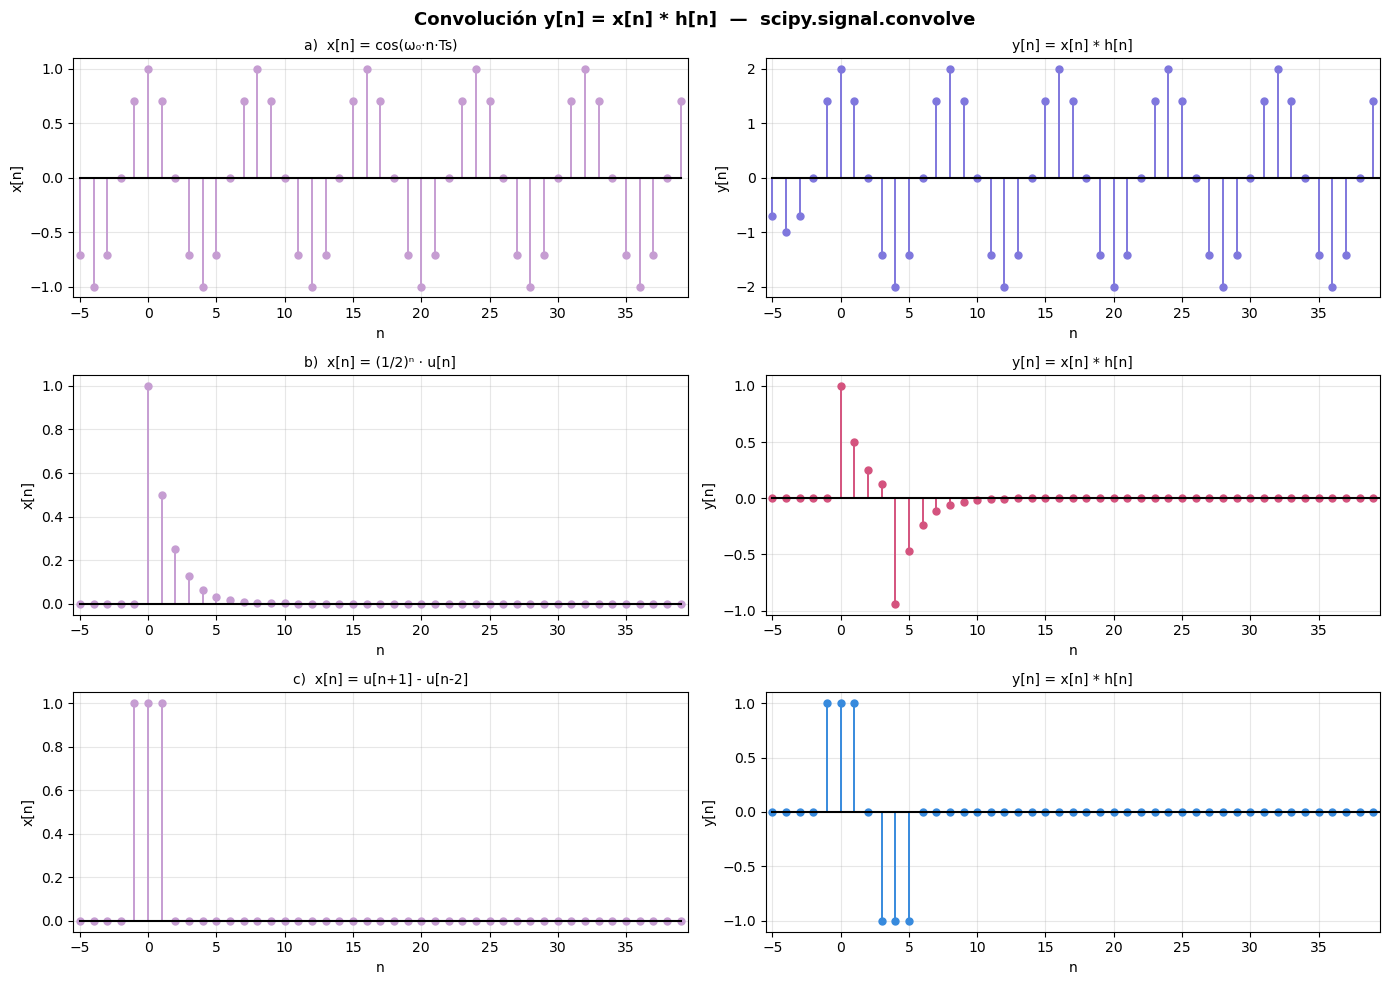

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

def delta(n):
    return (n == 0).astype(float)

def u(n):
    return (n >= 0).astype(float)

# Rango de n para h[n] (corto, solo donde es no nulo)
n_h = np.arange(0, 5)
h = delta(n_h) - delta(n_h - 4)

# Rango de n para las señales de entrada
n = np.arange(-5, 40)
w0 = np.pi / 4
Ts = 1

# Señales de entrada
x_a = np.cos(w0 * n * Ts)
x_b = (0.5 ** n) * u(n)
x_c = u(n + 1) - u(n - 2)

# Convolución numérica con scipy
y_a = convolve(x_a, h, mode='full')
y_b = convolve(x_b, h, mode='full')
y_c = convolve(x_c, h, mode='full')

# Vector de tiempo para las salidas
# Arranca donde arranca 'n' y tiene la longitud de la convolución full
n_y = np.arange(n[0], n[0] + len(y_a))

color_x  = '#C69DD2'
colors_y = ['#7F77DD', '#D4537E', '#378ADD']

configs = [
    (x_a, y_a, "a)  x[n] = cos(ω₀·n·Ts)",      "y[n] = x[n] * h[n]"),
    (x_b, y_b, "b)  x[n] = (1/2)ⁿ · u[n]",     "y[n] = x[n] * h[n]"),
    (x_c, y_c, "c)  x[n] = u[n+1] - u[n-2]",   "y[n] = x[n] * h[n]"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Convolución y[n] = x[n] * h[n]  —  scipy.signal.convolve",
             fontsize=13, fontweight='bold')

for i, (x, y, title_x, title_y) in enumerate(configs):
    # Agregamos los vectores de tiempo [n, n_y] al zip
    for ax, data, time_vec, title, color in zip(
        axes[i],
        [x, y],
        [n, n_y], 
        [title_x, title_y],
        [color_x, colors_y[i]]
    ):
        markerline, stemlines, baseline = ax.stem(
            time_vec, data, linefmt='-', markerfmt='o', basefmt='k-')
        markerline.set_color(color)
        markerline.set_markersize(5)
        stemlines.set_color(color)
        stemlines.set_linewidth(1.4)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("n")
        ax.set_ylabel("x[n]" if ax == axes[i][0] else "y[n]")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(n[0] - 0.5, n[-1] + 0.5)

plt.tight_layout()
plt.show()

## Conclusiones sobre el ejercicio 2

Como puede observarse, los resultados obtenidos analíticamente coinciden con los verificados mediante la convolución numérica implementada con `scipy.signal.convolve`, lo que confirma la validez del procedimiento empleado.

El sistema definido por $h[n] = \delta[n] - \delta[n-4]$ se comporta como un filtro de diferencia de orden 4, ya que por definición de convolución:

$$y[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n-k] = x[n] - x[n-4]$$

Es decir, la salida en cada instante es la diferencia entre la muestra actual y la que ocurrió 4 instantes antes, lo que hace que el sistema resalte cambios y cancele regiones constantes.


#### Caso a) $x[n] = \cos(\omega_0 \cdot n \cdot T_s)$

Aplicando la convolución directamente:

$$y[n] = \cos(\omega_0 n T_s) - \cos(\omega_0 (n-4) T_s)$$

Usando la identidad trigonométrica 
$\cos(\alpha) - \cos(\beta) = -2\sin\!\left(\frac{\alpha+\beta}{2}\right)\sin\!\left(\frac{\alpha-\beta}{2}\right)$
con $\omega_0 = \pi/4$ y $T_s = 1$:

$$y[n] = 2\sin(2\omega_0 T_s)\cos\!\left(\omega_0 n T_s - 2\omega_0 T_s + \frac{\pi}{2}\right)$$

La simulación numérica confirma que la salida mantiene la misma frecuencia que la entrada pero con amplitud duplicada ($A = 2$) y un desfase, comportamiento esperable en un SLIT ante una entrada sinusoidal.


#### Caso b) $x[n] = \left(\frac{1}{2}\right)^n u[n]$

La salida es:

$$y[n] = \left(\frac{1}{2}\right)^n u[n] - \left(\frac{1}{2}\right)^{n-4} u[n-4]$$

La convolución numérica permite observar con precisión tres regiones:

- **$0 \leq n < 4$**: transitorio positivo, donde el término retrasado aún es nulo
- **$n = 4$**: la salida cruza cero
- **$n > 4$**: valores negativos que tienden a cero, ya que 
$\left(\frac{1}{2}\right)^n \ll \left(\frac{1}{2}\right)^{n-4}$

Este comportamiento refleja cómo el sistema detecta la variación de la exponencial: grande al inicio, nula en régimen permanente.


#### Caso c) $x[n] = u[n+1] - u[n-2]$

La entrada es un pulso rectangular de duración finita (muestras $n = -1, 0, 1$). 
La salida del sistema identifica claramente:

- El flanco de subida del pulso (valor positivo): cuando $x[n]$ se activa
- Una zona nula intermedia: donde ambas contribuciones se cancelan  
- El flanco de bajada desplazado (valor negativo): cuando $x[n-4]$ se resta


#### Conclusión general

En todos los casos, `scipy.signal.convolve` permite verificar de forma directa el efecto del SLIT sobre distintos tipos de señales. El sistema actúa 
resaltando cambios y cancelando regiones constantes:

- Ante señales periódicas (caso a): modifica amplitud y fase pero preserva la frecuencia
- Ante señales que decaen (caso b): produce un transitorio y luego tiende a cero
- Ante señales con bordes abruptos (caso c): detecta los flancos de subida y bajada